## Narcissus Poisoned

In [3]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data
df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/PureGen/From_Scratch/Narcissus/PoisonedGen.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

MODEL = 'ResNet18_HLB'

### Filter Data
df = df[df['Model'] == MODEL]

df_results = []
for data_key in df['Data Key'].unique():
    for eps in df['noise_eps_narcissus'].unique():
        df_filt = df[(df['Data Key'] == data_key) & (df['noise_eps_narcissus'] == eps)]

        if df_filt.empty: continue

        # Extract the defense name
        label = data_key.split('[')[0]

        if label == 'EBM': continue

        # Get Steps
        if label in ['DM_UNET']:
            steps = int(data_key.split('_T[')[1].split(']')[0])
            if eps == 8:
                if steps != 75: continue
            if eps == 16:
                if steps != 125: continue
        else:
            steps = int(data_key.split('Steps[')[1].split(']')[0])
            if eps == 8:
                if steps != 150: continue
            if eps == 16:
                if steps != 750: continue
            
        # Get Eps
        try:
            gen_eps = data_key.split('eps=')[1].split(']')[0]
        except:
            gen_eps = 0

        df_results.append({'Defense': 'PureEBM' if label == 'EBMSNGAN32' else 'PureDDPM',
                            'Steps': steps,
                            'Defense Str': f"PureEBM-{steps}" if label == 'EBMSNGAN32' else f"PureDDPM-{steps}",
                            'PureGen Eps': int(gen_eps),
                            'Eps': eps,
                            'Nat Acc': df_filt['End Acc'].mean(),
                            'Nat Acc Str': f"{df_filt['End Acc'].mean()*100:.2f}\u00B1{df_filt['End Acc'].std()*100:.2f}",
                            'Poison Success': df_filt['P1 Acc'].mean(),
                            'Poison Success Str': f"{df_filt['P1 Acc'].mean()*100:.2f}\u00B1{df_filt['P1 Acc'].std()*100:.2f}",
                            'Max Poison Success': df_filt['P1 Acc'].max(),
                            'Max Poison Success Str': f"{df_filt['P1 Acc'].max()*100:.2f}",
                            'Num Results': len(df_filt),
                        })

df_results = pd.DataFrame(df_results)
# df_results.sort_values(by=['Defense','Eps','PureGen Eps'], inplace=True)
df_results.pivot(index=['PureGen Eps','Defense'], columns='Eps', values=['Nat Acc Str', 'Poison Success Str', 'Max Poison Success Str'])
# print(df_results.pivot(index=['PureGen Eps','Defense'], columns='Eps', values=['Nat Acc Str', 'Poison Success Str', 'Max Poison Success Str']).to_latex())

Nat Acc Str             Poison Success Str               \
Eps                           8           16                 8            16   
PureGen Eps Defense                                                            
0           PureDDPM  91.51±0.13  90.31±0.18          2.62±3.75    4.61±3.99   
            PureEBM   91.37±0.14  88.21±0.15          1.60±0.82    8.73±6.29   
8           PureDDPM  88.99±0.16  85.24±0.10          1.65±0.79    4.79±2.83   
            PureEBM   91.11±0.18  87.60±0.18          1.55±0.89    5.35±3.30   
16          PureDDPM  88.02±0.21  83.74±0.21          1.57±0.79    2.90±1.54   
            PureEBM   90.76±0.14  85.58±0.40          1.28±0.86  17.73±14.62   

                     Max Poison Success Str         
Eps                                      8      16  
PureGen Eps Defense                                 
0           PureDDPM                  12.70  12.86  
            PureEBM                    2.82  23.05  
8           PureDDPM                   2.87  10.53  
            PureEBM                    2.87  12.05  
16          PureDDPM                   2.79   6.11  
            PureEBM                    3.43  44.15

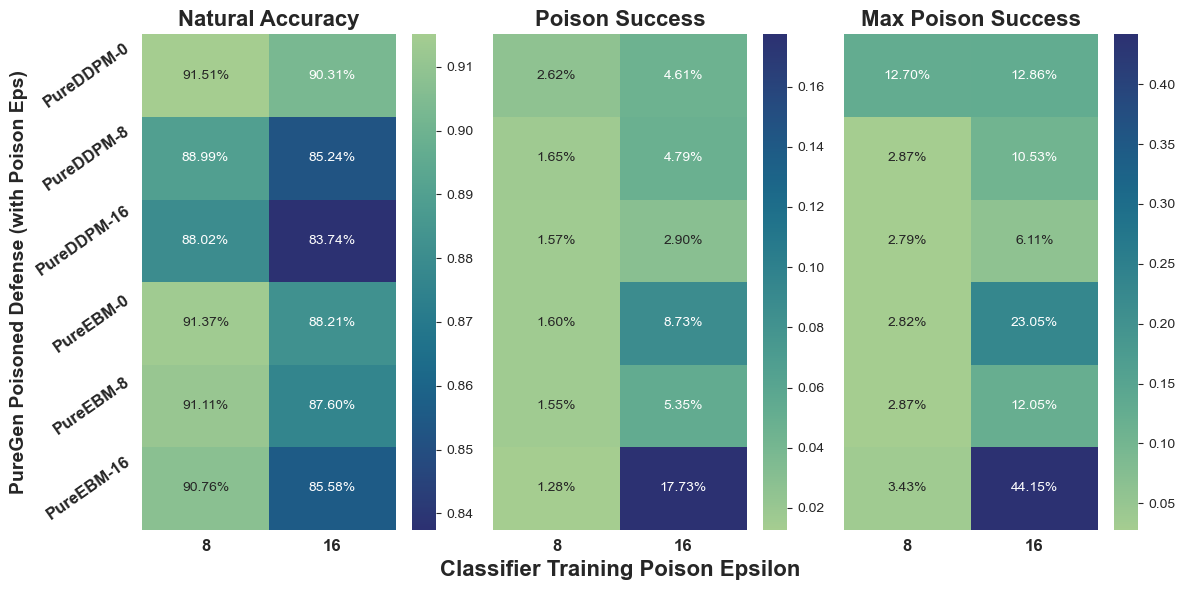

In [8]:
fig,axs = plt.subplots(1,3, figsize=(12,6))

sns.heatmap(df_results.pivot(index=['Defense','PureGen Eps'], columns='Eps', values='Nat Acc'), annot=True, fmt=".2%", cmap='crest_r', ax=axs[0])
# Format annot to be bold
axs[0].set_title('Natural Accuracy', fontsize=16, fontweight='bold')
axs[0].set_ylabel('PureGen Poisoned Defense (with Poison Eps)', fontsize=14, fontweight='bold')
axs[0].set_xlabel('')
# Rotate y tick labels
axs[0].set_yticklabels(axs[0].get_yticklabels(), rotation=35, fontsize=12, fontweight='bold')
axs[0].set_xticklabels(axs[0].get_xticklabels(), fontsize=12, fontweight='bold')


sns.heatmap(df_results.pivot(index=['Defense','PureGen Eps'], columns='Eps', values='Poison Success'), annot=True, fmt=".2%", cmap='crest', ax=axs[1])
axs[1].set_title('Poison Success', fontsize=16, fontweight='bold')
axs[1].set_ylabel('')
axs[1].set_xlabel('Classifier Training Poison Epsilon', fontsize=16, fontweight='bold')
axs[1].set_yticks([])
axs[1].set_xticklabels(axs[1].get_xticklabels(), fontsize=12, fontweight='bold')

sns.heatmap(df_results.pivot(index=['Defense','PureGen Eps'], columns='Eps', values='Max Poison Success'), annot=True, fmt=".2%", cmap='crest', ax=axs[2])
axs[2].set_title('Max Poison Success', fontsize=16, fontweight='bold')
axs[2].set_ylabel('')
axs[2].set_xlabel('')
axs[2].set_yticks([])
axs[2].set_xticklabels(axs[2].get_xticklabels(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'PoisonedGen.pdf', dpi=300,bbox_inches='tight')

## All Step Plots

In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

### Load Data
df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/PureGen/From_Scratch/Narcissus/PoisonedGen.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

EPS = 16
MODEL = 'ResNet18_HLB'

### Filter Data
df = df[df['noise_eps_narcissus'] == EPS]
df = df[df['Model'] == MODEL]

df_results = []
for data_key in df['Data Key'].unique():
    df_filt = df[df['Data Key'] == data_key]

    # Extract the defense name
    label = data_key.split('[')[0]

    if label == 'EBM': continue

    # Get Steps
    if label in ['DM_UNET']:
        steps = int(data_key.split('_T[')[1].split(']')[0])
    else:
        steps = int(data_key.split('Steps[')[1].split(']')[0])

    # Get Eps
    try:
        eps = data_key.split('eps=')[1].split(']')[0]
    except:
        eps = 0

    df_results.append({'Defense': 'PureEBM' if label == 'EBMSNGAN32' else 'PureDDPM',
                        'Steps': steps,
                        'Defense Str': f"PureEBM-{steps}" if label == 'EBMSNGAN32' else f"PureDDPM-{steps}",
                        'Eps': int(eps),
                        'Nat Acc': df_filt['End Acc'].mean(),
                        'Nat Acc Str': f"{df_filt['End Acc'].mean()*100:.2f}\u00B1{df_filt['End Acc'].std()*100:.2f}",
                        'Poison Success': df_filt['P1 Acc'].mean(),
                        'Poison Success Str': f"{df_filt['P1 Acc'].mean()*100:.2f}\u00B1{df_filt['P1 Acc'].std()*100:.2f}",
                        'Max Poison Success': df_filt['P1 Acc'].max(),
                        'Max Poison Success Str': f"{df_filt['P1 Acc'].max()*100:.2f}",
                        'Num Results': len(df_filt),
                    })

df_results = pd.DataFrame(df_results)
df_results.sort_values(by=['Defense','Eps'], inplace=True)
df_results

,Defense,Steps,Defense Str,Eps,Nat Acc,Nat Acc Str,Poison Success,Poison Success Str,Max Poison Success,Max Poison Success Str,Num Results
14,PureDDPM,150,PureDDPM-150,0,0.89752,89.75±0.17,0.048008,4.80±5.28,0.183143,18.31,10
16,PureDDPM,125,PureDDPM-125,0,0.90315,90.31±0.18,0.046052,4.61±3.99,0.128609,12.86,10
18,PureDDPM,100,PureDDPM-100,0,0.90880,90.88±0.13,0.062493,6.25±6.63,0.228785,22.88,10
20,PureDDPM,75,PureDDPM-75,0,0.91412,91.41±0.14,0.087014,8.70±8.71,0.288138,28.81,10
13,PureDDPM,150,PureDDPM-150,8,0.83455,83.45±0.19,0.046316,4.63±2.57,0.094432,9.44,10
15,PureDDPM,125,PureDDPM-125,8,0.85241,85.24±0.10,0.047916,4.79±2.83,0.105304,10.53,10
17,PureDDPM,100,PureDDPM-100,8,0.87111,87.11±0.17,0.053539,5.35±3.78,0.132416,13.24,10
19,PureDDPM,75,PureDDPM-75,8,0.88975,88.97±0.10,0.059681,5.97±4.16,0.137896,13.79,10
9,PureDDPM,150,PureDDPM-150,16,0.81794,81.79±0.15,0.029021,2.90±1.39,0.056580,5.66,10
10,PureDDPM,125,PureDDPM-125,16,0.83744,83.74±0.21,0.028999,2.90±1.54,0.061092,6.11,10


/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_47780/4089261916.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_yticklabels(['{:,.1%}'.format(x) for x in axs[0].get_yticks()])
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_47780/4089261916.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_yticklabels(['{:,.1%}'.format(x) for x in axs[1].get_yticks()])
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_47780/4089261916.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[2].set_yticklabels(['{:,.1%}'.format(x) for x in axs[2].get_yticks()])


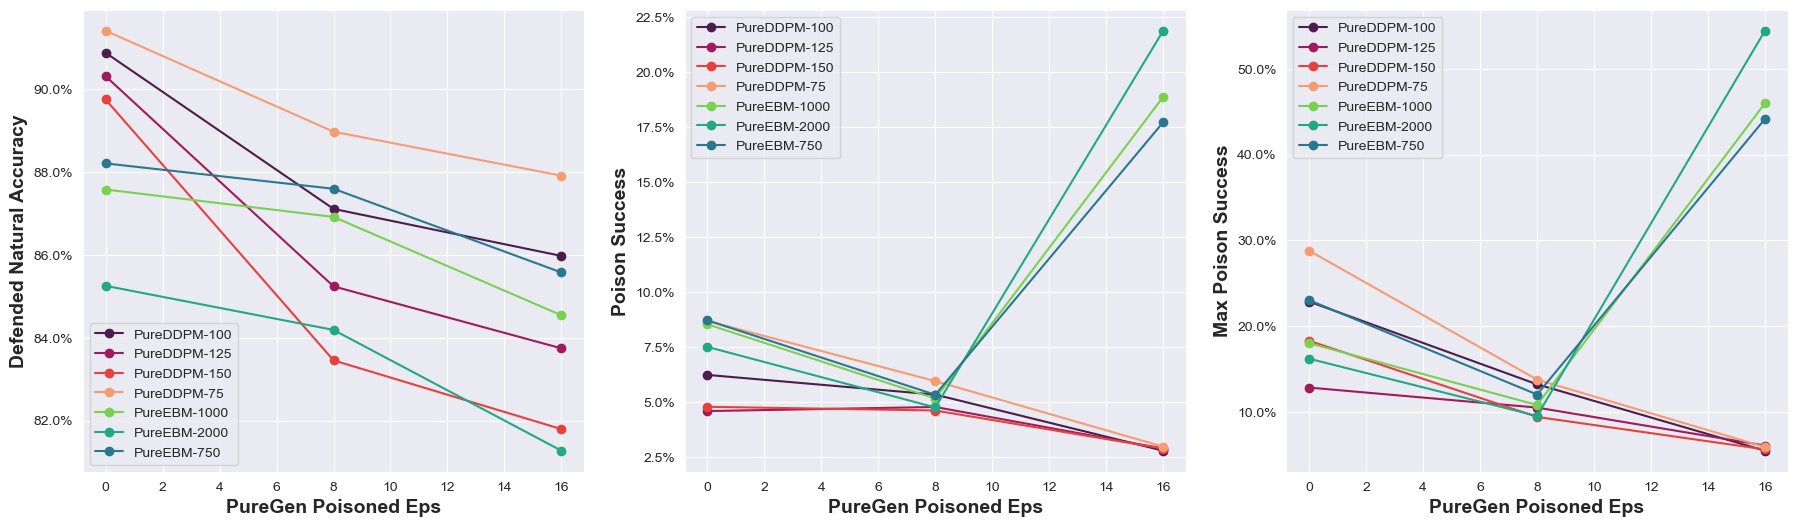

In [16]:

fig, axs = plt.subplots(1, 3, figsize=(22, 6))

# Natural Accuracy
pivot_table = df_results.pivot(index='Defense Str', columns='Eps', values='Nat Acc') 
cmap = sns.color_palette('rocket', 4) + sns.color_palette('viridis_r', 4)
for i, row in enumerate(pivot_table.iterrows()):
    index, values = row
    axs[0].plot(pivot_table.columns, values, marker='o', color=cmap[i], label=index)
axs[0].set_xlabel('PureGen Poisoned Eps', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Defended Natural Accuracy', fontsize=14, fontweight='bold')
axs[0].set_yticklabels(['{:,.1%}'.format(x) for x in axs[0].get_yticks()])
axs[0].legend()

# Poison Success
pivot_table = df_results.pivot(index='Defense Str', columns='Eps', values='Poison Success')
cmap = sns.color_palette('rocket', 4) + sns.color_palette('viridis_r', 4)
for i, row in enumerate(pivot_table.iterrows()):
    index, values = row
    axs[1].plot(pivot_table.columns, values, marker='o', color=cmap[i], label=index)

axs[1].set_xlabel('PureGen Poisoned Eps', fontsize=14, fontweight='bold')
axs[1].set_ylabel('Poison Success', fontsize=14, fontweight='bold')
axs[1].set_yticklabels(['{:,.1%}'.format(x) for x in axs[1].get_yticks()])
axs[1].legend()

# Max Poison Success
pivot_table = df_results.pivot(index='Defense Str', columns='Eps', values='Max Poison Success')
cmap = sns.color_palette('rocket', 4) + sns.color_palette('viridis_r', 4)
for i, row in enumerate(pivot_table.iterrows()):
    index, values = row
    axs[2].plot(pivot_table.columns, values, marker='o', color=cmap[i], label=index)

axs[2].set_xlabel('PureGen Poisoned Eps', fontsize=14, fontweight='bold')
axs[2].set_ylabel('Max Poison Success', fontsize=14, fontweight='bold')
axs[2].set_yticklabels(['{:,.1%}'.format(x) for x in axs[2].get_yticks()])
axs[2].legend()

plt.savefig(f'PoisonedGen_Narc{EPS}_Steps.pdf', dpi=300,bbox_inches='tight')